# 01. Reconstruct MS spectra

case1
['IGHM:11610.5:0.189:2.0:Serum:nan:nan:nan', 'IGHM:11556.4:0.0479:2.0:Serum:nan:nan:nan']
Gaussian peaks of case1: 11620.41


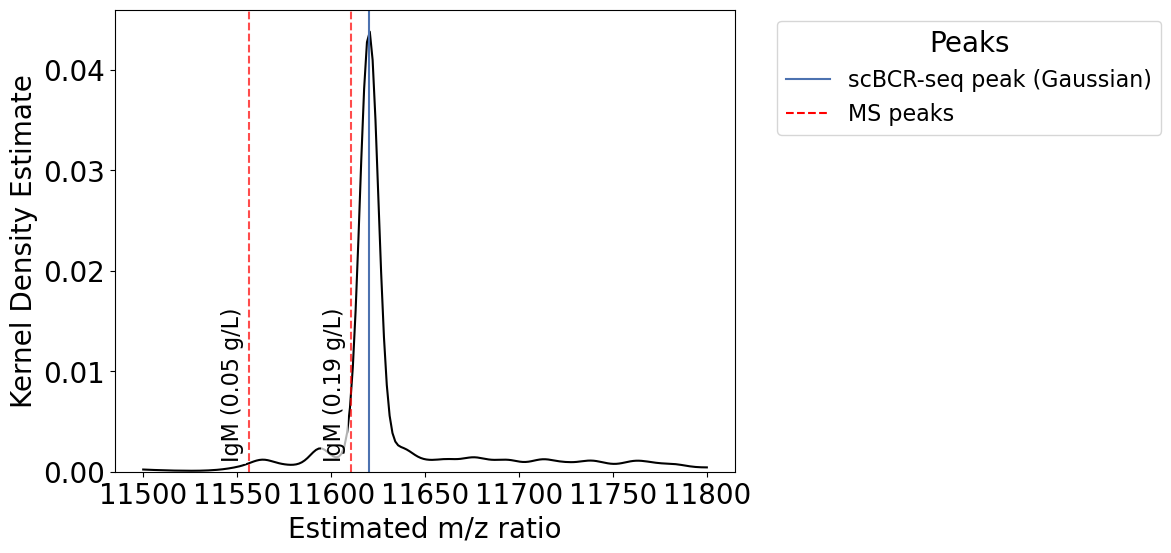

case2
['IGHA_IGKC:11705.62984:2.25:2.0:Plasma:69.38:F:nan', 'IGHM:11759.52036:0.059:2.0:Plasma:69.38:F:nan']
Gaussian peaks of case2: 11754.97


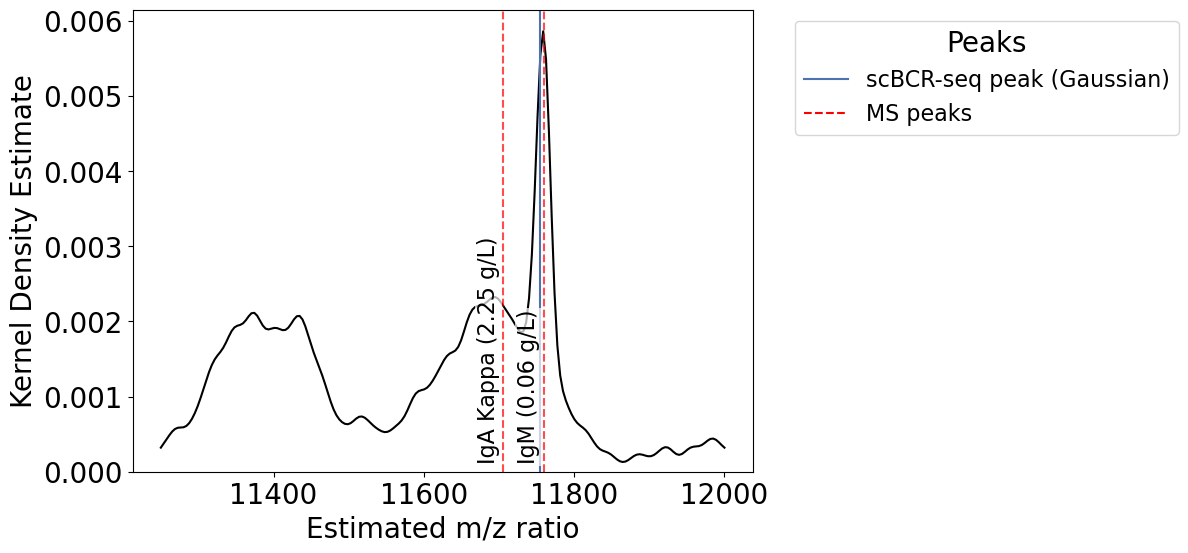

In [3]:
import pandas as pd
import numpy as np
import os, glob, subprocess, itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import colorcet as cc
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

heavy_chain_dict = {
    "IGHM" : "IgM",
    "IGHA" : "IgA",
    "IGHG" : "IgG"
}

light_chain_dict = {
    "IGLC" : "Lambda",
    "IGKC" : "Kappa"
}

ms_dict = {
    'case1' : ['IGHM:11610.5:0.189:2.0:Serum:nan:nan:nan', 'IGHM:11556.4:0.0479:2.0:Serum:nan:nan:nan'],
    'case2' : ['IGHA_IGKC:11705.62984:2.25:2.0:Plasma:69.38:F:nan', 'IGHM:11759.52036:0.059:2.0:Plasma:69.38:F:nan']
    
}

#for sample in joined_df['demux_id'].unique():
for sample in ['case1', 'case2']:
    input_df = pd.read_csv(f'../data/PROMISE_{sample}_BCR.csv')
    
    ms_results = ms_dict[sample] 
    
    x_values = []
    annotations = []

    for item in ms_results:
        parts = item.split(":")
        isotype, ms_mz_ratio, conc = parts[0], parts[1], parts[2]
        if "_" in isotype:
            hc, lc = isotype.split("_")
            heavy_chain = heavy_chain_dict[hc]
            light_chain = light_chain_dict[lc]
            isotype_final = heavy_chain + " " + light_chain
        else:
            isotype_final = heavy_chain_dict[isotype]
        x_values.append(float(ms_mz_ratio))
        annotations.append(f"{isotype_final} ({float(conc):.2f} g/L)")
    
    print(sample)
    print(ms_results)
    plt.figure(figsize=(8, 6))
    plt.rcParams.update({'font.size': 20})
    
    # Compute KDE manually to find peaks
    kde = gaussian_kde(input_df['est_mz_ratio'], bw_method=0.1)
    x_range = np.linspace(input_df['est_mz_ratio'].min(), 
                          input_df['est_mz_ratio'].max(), 
                          5000)
    y_kde = kde(x_range)

    # Find peaks in the KDE
    peaks_indices, _ = find_peaks(y_kde, prominence=0.002, distance=10)  
    peaks_x = x_range[peaks_indices]
    
    if sample == 'case1':
        clip = (11500, 11800)
        x_offset = 15
        y_ms_text = 0.001
    else:
        clip = (11250, 12000)
        x_offset = 35
        y_ms_text = 0.0001
    
    sns.kdeplot(
        input_df['est_mz_ratio'], 
        fill=False,
        color='black', 
        clip=clip,
        bw_adjust=0.2,
    )
    
    # Draw lines for peaks_x
    colors = sns.color_palette("deep", 5)
    handles = []
    for x, label in zip(peaks_x, annotations):
        line = plt.axvline(x=x, color=colors[0], linestyle='-', 
                           alpha=1, 
                           #label=f"Gaussian peaks, {x:.2f}"
                           label="scBCR-seq peak (Gaussian)"
                          )
        #handles.append(line)
        print(f"Gaussian peaks of {sample}: {x:.2f}")
        
    for x, label in zip(x_values, annotations):
        plt.axvline(x=x, color='red', linestyle='--', 
                    alpha=0.7, 
        )
        
        # text (above x)
        plt.text(
            x - x_offset,     
            y_ms_text,    
            label,                
            rotation=90,          
            color='black',
            fontsize=16,
            ha='left',
            va='bottom',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1.5)  
        )

    # Legend
    custom_lines = (
        [plt.Line2D([0], [0], color=colors[0], linestyle='-', label='scBCR-seq peak (Gaussian)')] +
        [plt.Line2D([0], [0], color='red', linestyle='--', label=f"MS peaks")]
    )
        
    plt.legend(handles=custom_lines, title="Peaks", bbox_to_anchor=(1.05, 1), 
               loc='upper left', fontsize=16)
    
    plt.xlabel("Estimated m/z ratio")
    plt.ylabel("Kernel Density Estimate")
    
    plt.savefig(f'../00.Figures/{sample}_recon_MS_spectra.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    

# 02. UMAP and analysis

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import scanpy.external as sce
import os, glob, subprocess, itertools
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import wilcoxon
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample
from scipy.stats import permutation_test
from scipy.stats import bootstrap
from Levenshtein import distance as levenshtein_distance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def draw_umap(adata, group, ssample):
    res=0.2
    sc.tl.pca(adata, svd_solver='arpack')
    try:
        sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
    except Exception as e:
        sc.pp.neighbors(adata, n_neighbors=5, n_pcs=10)
    sc.tl.leiden(adata, resolution=float(res))
    sc.tl.paga(adata)
    sc.pl.paga(adata, plot=False)  
    sc.tl.umap(adata, init_pos='paga')
  
    ### Label
    adata.obs['clonotype_number'] = adata.obs['clonotype_number'].astype(str).str.split(".").str[0]
    adata.obs['clonotype_top10'] = adata.obs['clonotype_top10'].astype(str).str.split(".").str[0]
    
    adata.obs['dref_aa_present'] = np.where(
                                    adata.obs['dref_aa'].isna(), 'NA',
                                    np.where(adata.obs['dref_aa'] >= 1, 'SHM', 'no SHM')
                                   )
    
    adata.obs[f'{group}_clonotype'] = np.where(adata.obs[group] == 'MGIP',
                                               adata.obs['clonotype_number'],
                                               'N')

    
    # Pallete
    custom_palette = dict(zip([str(i) for i in range(1, 11)], sns.color_palette("deep", 10)))

    extra_palette = {
        'SHM': 'red',
        'no SHM': 'lightblue',
        'NA': 'lightgrey',
        'Y': 'red',
        'N': 'lightgrey',
        'Others': 'lightgrey',
        'MGIP': 'red',
        'NaN': 'lightgrey'
    }

    # Combine both palettes
    palette = {**custom_palette, **extra_palette}
    
    # Step 1: relabel 'clonotype_top10' with n= count
    colname = 'clonotype_top10'
    label_counts = adata.obs[colname].value_counts()

    label_map = {label: f"{label} (n={label_counts[label]:,})" for label in label_counts.index}
    adata.obs[f'{colname}_labeled'] = adata.obs[colname].map(label_map)

    for label in adata.obs[f'{colname}_labeled'].unique():
        base_label = label.split(" (n=")[0]
        if base_label in palette:
            palette[label] = palette[base_label]
        else:
            palette[label] = 'grey'  # default fallback

    # Step 2: relabel group column (e.g., 'MGIP') with n=
    group_counts = adata.obs[group].value_counts()
    group_label_map = {label: f"{label} (n={group_counts[label]:,})" for label in group_counts.index}
    adata.obs[f'{group}_labeled'] = adata.obs[group].map(group_label_map)

    for label in adata.obs[f'{group}_labeled'].unique():
        base_label = label.split(" (n=")[0]
        if base_label in palette:
            palette[label] = palette[base_label]
        else:
            palette[label] = 'lightgrey'

    
    
    for cc in ['cell_annot_final']:
    #for cc in [ 'clonotype_top10', 'cell_annot_final', ]:
                #f'{group}_clonotype', f'{group}_clonal_aa', f'{group}_clonal_10x']: 
        clonotypes = adata.obs[cc].unique()
        default_col = sns.color_palette("deep", len(clonotypes))
        col_idx = 0
        for x in clonotypes:
            if x not in palette:
                palette[x] = default_col[col_idx]
                col_idx +=1 
    
    plt.rcParams.update({'font.size': 20})
    
    ## Clonotype top 10
    fig, ax = plt.subplots()
    sc.pl.embedding(adata, basis='X_umap', 
                    color = ['clonotype_top10_labeled'],
                    palette = palette,
                    title = 'Top 10 Clonotypes',
                    ax=ax, show=False
                   )
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    fig.savefig(f'../00.Figures/PROMISE_{ssample}_clonotypetop10.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    
    ## MGIP
    fig, ax = plt.subplots()
    group2 = "".join(group.split(" "))
    sc.pl.embedding(adata, basis='X_umap', 
                    color = [f'{group}_labeled'],
                    palette = palette,
                    title = 'MGIP',
                    ax=ax, show=False
                   )
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    fig.savefig(f'../00.Figures/PROMISE_{ssample}_{group2}.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    
    sc.pl.embedding(adata, basis='X_umap',
                    color = ['cell_annot_final'])
    
    sc.pl.embedding(adata, basis='X_umap', 
                    color = ['clonotype_top10', group, 'dref_aa_present'],
                    palette = palette
                   )
    

def DEG(adata_subset, group, sample):
    ## DEG
    sc.tl.rank_genes_groups(adata_subset, group, method='wilcoxon', key_added = "rank_genes_groups")#,
                           #groups = [attr1], reference = attr2)
    #sc.pl.rank_genes_groups(adata_subset, n_genes=20, sharey=False, key="rank_genes_groups")

    deg = sc.get.rank_genes_groups_df(adata_subset, group='MGIP')

    # Genes to be removed
    sex_specific_malat1_genes = ['XIST', 'RPS4Y1', 'DDX3Y', 'MALAT1']
    ig_genes = [gene_name for gene_name in deg['names'].unique() if gene_name.startswith('IG')]
    mt_genes = [gene_name for gene_name in deg['names'].unique() if gene_name.startswith('MT-')]
    ribo_genes1 = [gene_name for gene_name in deg['names'].unique() if gene_name.startswith('RPS')]
    ribo_genes2 = [gene_name for gene_name in deg['names'].unique() if gene_name.startswith('RPL')]
    remove_genes = set(sex_specific_malat1_genes + ig_genes + mt_genes + ribo_genes1 + ribo_genes2)

    deg = deg[~deg['names'].isin(remove_genes)]
    display(deg.sort_values('pvals_adj', ascending=True).head(30))
    up_reg = deg[(deg['logfoldchanges'] > 1) & (deg['pvals_adj'] < 0.05)]
    up_reg.to_csv(f'{sample}_mgip_upreg.csv', sep=",")
    up_reg_list = up_reg['names'].tolist()
    #print(up_reg_list)

#     if len(up_reg_list) >= 8: 
#         ## GSEA
#         gene_set_list = [
#                      '../data/h.all.v2023.2.Hs.symbols.gmt',
#         ]

#         enr_up = gp.enrichr(up_reg_list,
#                             gene_sets=gene_set_list,
#                             outdir=None)
#         try :
#             gp.dotplot(enr_up.res2d, figsize=(3,5)) #, title=f'{sample}_UpReg_mgip')
#             plt.show()
#             plt.close()
            
#             sig_enr = enr_up.res2d[enr_up.res2d['Adjusted P-value'] < 0.05]
#             sig_enr_results_sorted = sig_enr.sort_values(
#                 by=['Adjusted P-value', 'Combined Score'], 
#                 ascending=[True, False]
#             )
            
#             display(sig_enr_results_sorted.head(10))
#         except Exception as e:
#             print(f'{e}')
#             display(enr_up.res2d.head())
            
#     else:
#         print(f'{sample} has no or less than 8 up-regulated genes')




def cohen_d(group1, group2):
    diff = np.mean(group1) - np.mean(group2)
    pooled_std = np.sqrt((np.var(group1, ddof=1) * (len(group1) - 1) + 
                          np.var(group2, ddof=1) * (len(group2) - 1)) / 
                         (len(group1) + len(group2) - 2))
    return diff / pooled_std if pooled_std != 0 else np.nan


    
def gene_score(adata, score_name, score_genes, group):
    sc.tl.score_genes(adata, score_genes, ctrl_size=len(score_genes)*3, random_state=42,
                      #gene_pool=gene_dict.get(score_name, []) + gene_dict.get('housekeeping', []),
                      score_name=score_name)
    #df = adata.obs[['demux_id', 'cell_annot_final', 'clonotype_top10', score_name, group]]
    df = adata.obs[['demux_id', 'cell_annot_final', 'clonotype_top10', score_name, group]].reset_index()
    
    return df

top=50

gene_dict = {
    "Myeloma" : pd.read_csv('../data/UpSig_Freq.csv', sep=',').sort_values(by='Freq', ascending=False).head(top)['Gene'].tolist(),
    "WM" : pd.read_csv('../data/WM_gene_up_freq.csv', sep=',').sort_values(by='Freq', ascending=False).head(top)['wm_genes_up'].tolist(),
    "CLL" : pd.read_csv('../data/CLL_gene_up_freq.csv', sep=',').query('Freq > 1')['cll_genes_up'].tolist() + ['FCER2', 'LEF1', 'CD5', 'CD200', 'SPN', 'TCL1A'],
    "MCL" : ['SPARC', 'IL10RA', 'CTSS', 'BCL2', 'UBD', 'MIG', 'CSF1R', 'CCND1', 'HSPB2', 'ZNFN1A1', 'TGIF', 'DCTD'],
    "HCL" : ['IGHG', 'CCND1', 'ITGAE', 'CD19', 'GAS7', 'FGF2', 'FGFR1', 'RECK', 'TTN', 'CHL1', 'SEPINT10', 'RGS13', 'AICDA', 'EBI3', 'CD180', 'LAIR1', 'FCGR2B'],
    "Burkitt" : ['TERT', 'MYC', 'BYSL', 'MME', 'BUB1B', 'RFC3', 'RANBP1', 'NS', 'NOL5A', 'MAZ', 'RFC4', 'CDC7', 'TOP1', 'NP', 'MYBL1', 'CDK4'],
    "PC" : ['TNFRSF17', 'SDC1', 'XBP1', 'MZB1', 'CD19', 'MS4A1', 'NCAM1', 'CD27', 'PTPRC', 'KIT'],
    "Housekeeping" : ['ACTB', 'GAPDH', 'UBC', 'HPRT'] 
}


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


number of cell close to the first MS peak (correspond to scBCR peak)
MS_group  clonotype_top10
MGIP      1.0                1830
          Others                5
NaN       1.0                 350
          10.0                  2
          2.0                   2
          3.0                   1
          4.0                   4
          5.0                   3
          6.0                   2
          7.0                   1
          8.0                   2
          9.0                   2
          Others             1936
dtype: int64
clonotype_top10  MS_group
1.0              MGIP        1830
                 NaN          350
10.0             NaN            2
2.0              NaN            2
3.0              NaN            1
4.0              NaN            4
5.0              NaN            3
6.0              NaN            2
7.0              NaN            1
8.0              NaN            2
9.0              NaN            2
Others           MGIP           5
                

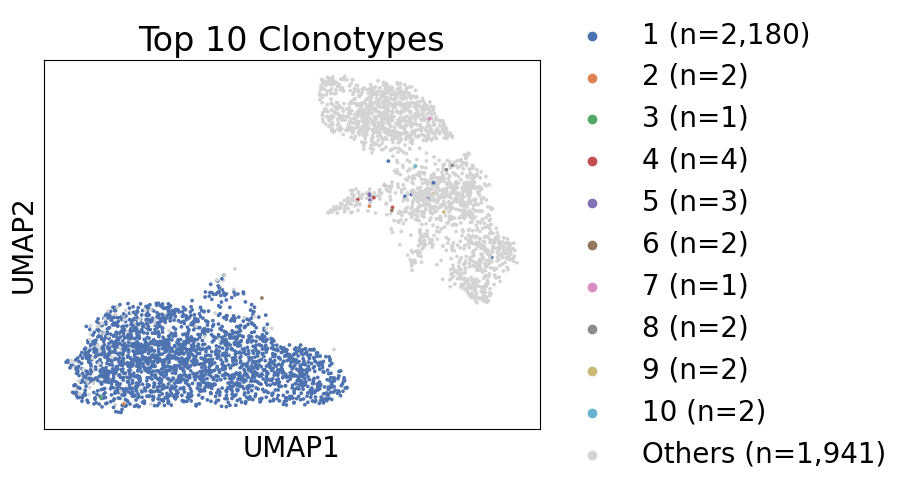

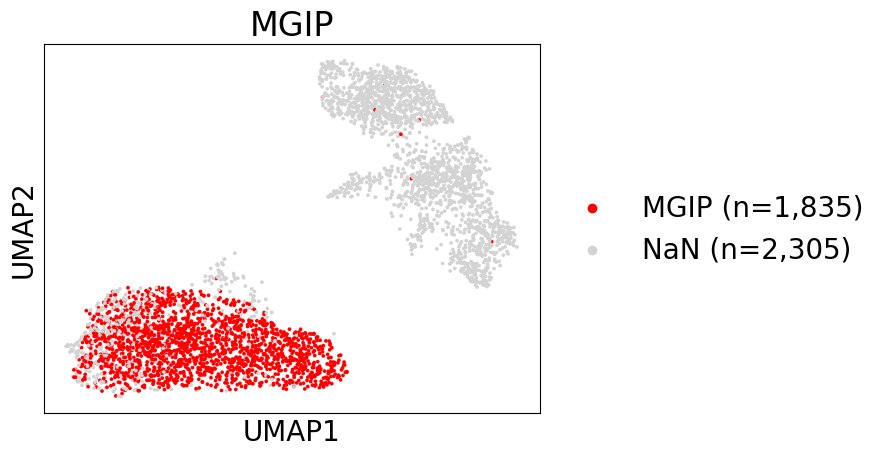

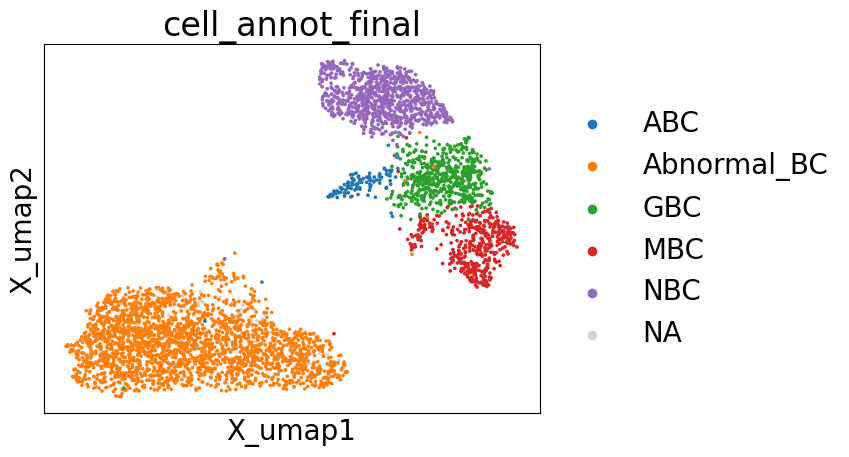

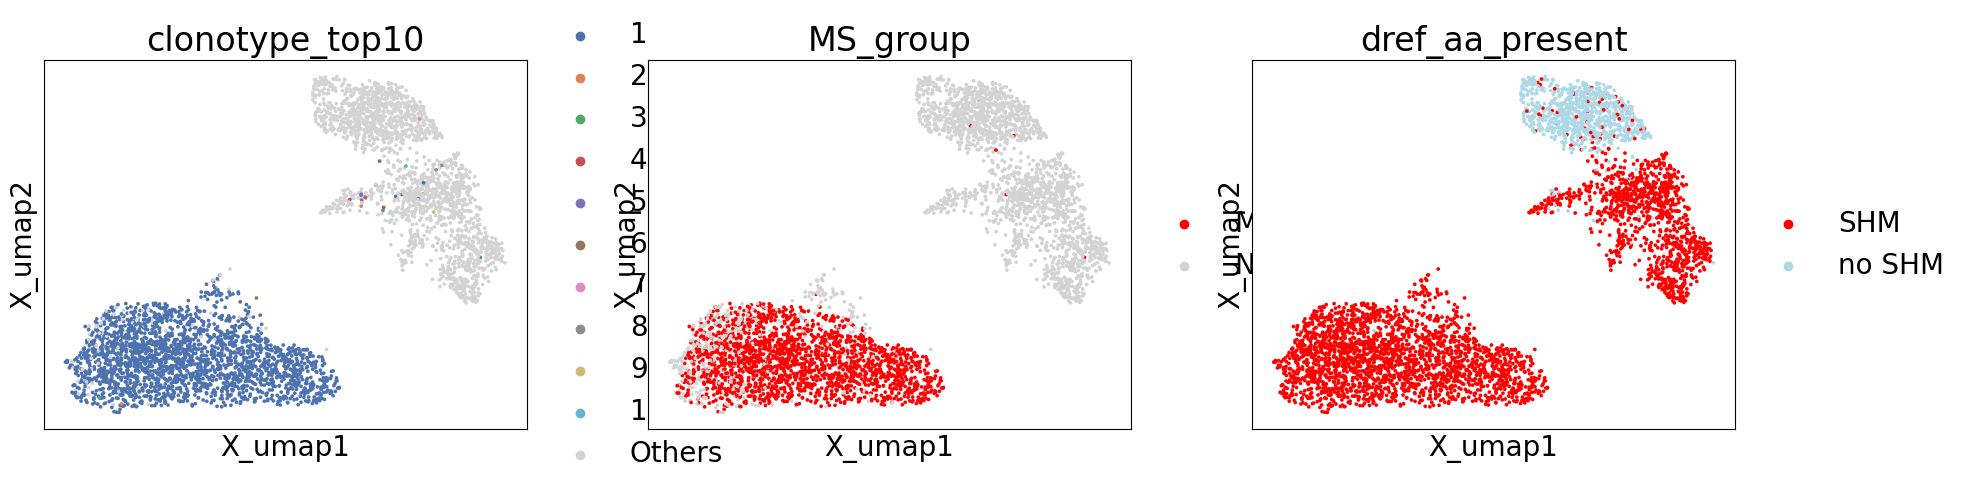

,names,scores,logfoldchanges,pvals,pvals_adj
4,CDV3,39.285103,6.111675,0.000000e+00,0.000000e+00
7,TCF4,37.899235,5.475263,0.000000e+00,0.000000e+00
8,LINC01857,36.877930,6.887809,1.043729e-297,2.737237e-294
9,YBX3,36.487389,6.371898,1.757765e-291,4.148854e-288
10,ACTG1,33.585445,6.716359,2.736538e-247,5.871865e-244
11,HLA-B,33.320202,29.367786,1.968745e-243,3.872358e-240
12,PMAIP1,33.161491,5.158737,3.867818e-241,7.022471e-238
13,TMSB10,32.949486,15.043430,4.302566e-238,7.253819e-235
14,MYL6,32.782597,4.352993,1.042446e-235,1.640324e-232
15,ACSM3,31.952290,3.609014,5.020977e-224,7.406883e-221


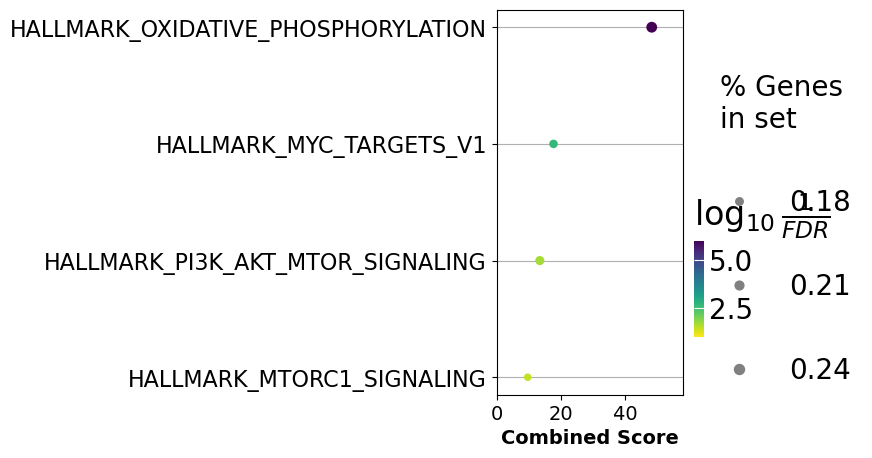

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
35,h.all.v2023.2.Hs.symbols.gmt,HALLMARK_OXIDATIVE_PHOSPHORYLATION,52/200,2.858315e-09,1.429158e-07,2.453957,48.276788,ATP6V1E1;MPC1;ACADM;LDHB;ATP5MC2;HSD17B10;OXA1...
31,h.all.v2023.2.Hs.symbols.gmt,HALLMARK_MYC_TARGETS_V1,41/200,8.944050e-05,2.236013e-03,1.893155,17.647872,SNRPD3;HNRNPA3;RACK1;EIF3B;SNRPD2;GNL3;PRDX4;A...
39,h.all.v2023.2.Hs.symbols.gmt,HALLMARK_PI3K_AKT_MTOR_SIGNALING,23/105,1.263383e-03,2.105639e-02,2.004739,13.379554,AP2M1;ITPR2;ARPC3;SQSTM1;CFL1;HSP90B1;ACTR2;PF...
30,h.all.v2023.2.Hs.symbols.gmt,HALLMARK_MTORC1_SIGNALING,36/200,2.928361e-03,3.660452e-02,1.647063,9.607835,RPN1;TFRC;SQSTM1;CORO1A;TUBA4A;ADD3;HSP90B1;CT...


MGIP cells in case1 = 1835
4140


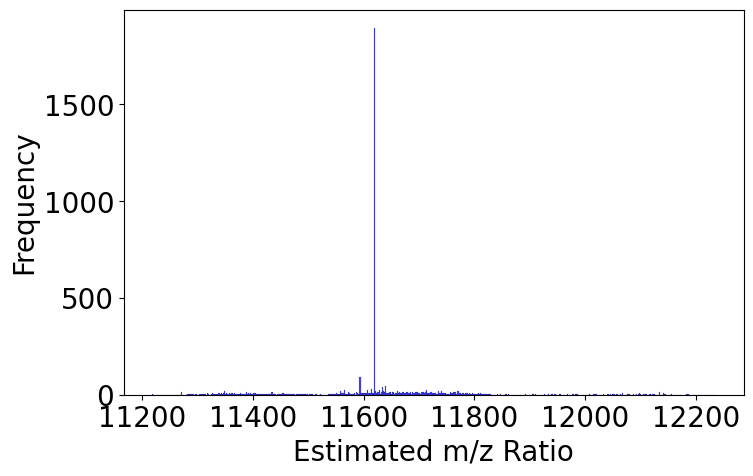

number of cell close to the first MS peak (correspond to scBCR peak)
MS_group  clonotype_top10
MGIP      1.0                 235
          Others                8
NaN       1.0                   1
          10.0                  2
          2.0                   3
          3.0                   2
          4.0                   2
          5.0                   2
          6.0                   1
          7.0                   1
          8.0                   2
          9.0                   2
          Others             1884
dtype: int64
clonotype_top10  MS_group
1.0              MGIP         235
                 NaN            1
10.0             NaN            2
2.0              NaN            3
3.0              NaN            2
4.0              NaN            2
5.0              NaN            2
6.0              NaN            1
7.0              NaN            1
8.0              NaN            2
9.0              NaN            2
Others           MGIP           8
                

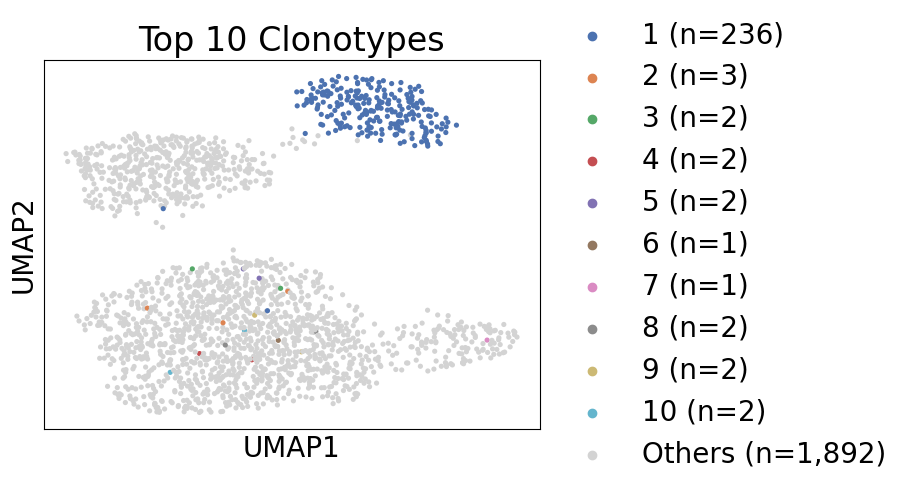

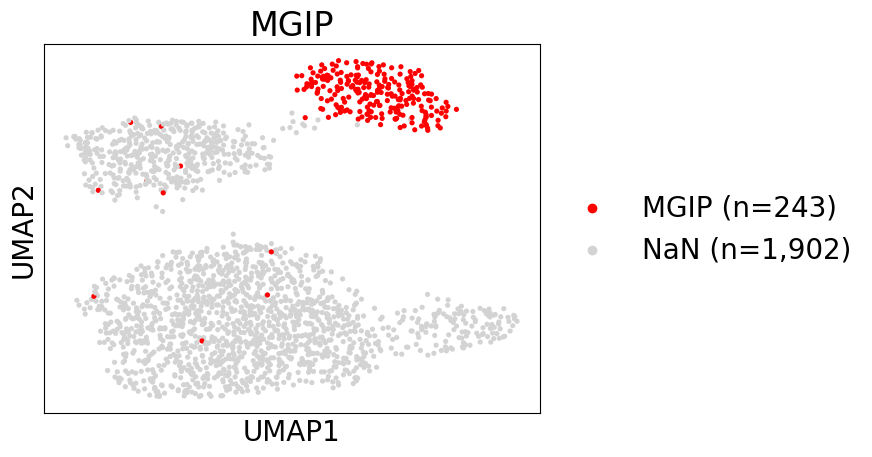

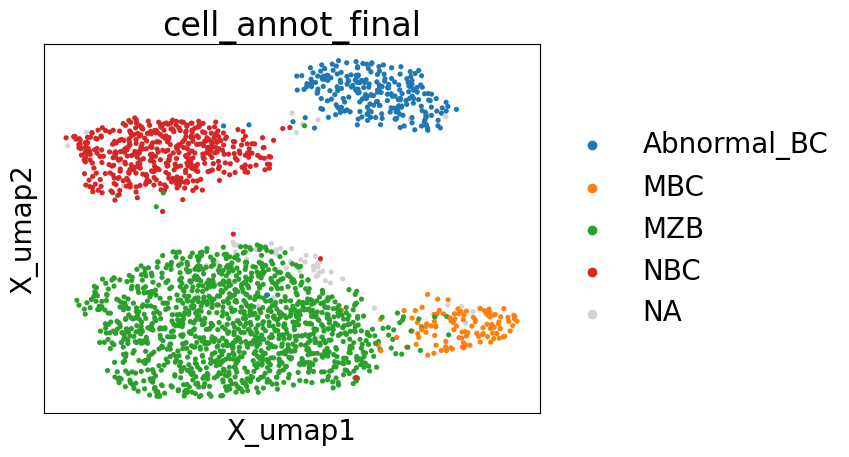

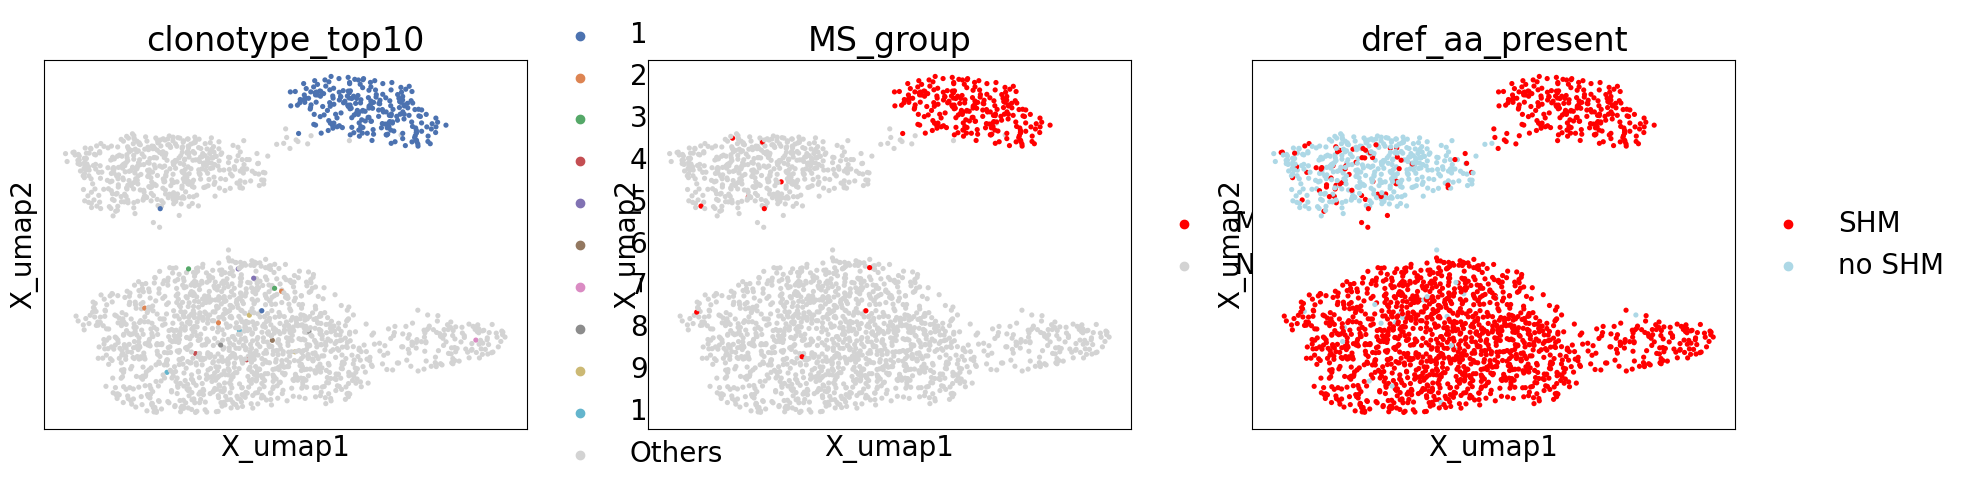

,names,scores,logfoldchanges,pvals,pvals_adj
2,YBX3,19.909939,6.060831,3.337180e-88,2.625582e-84
4,DUSP2,18.178144,11.567153,7.689045e-74,3.629691e-70
6,EGR1,16.121210,7.395950,1.810288e-58,4.272823e-55
23599,TXNIP,-15.971124,-10.799173,2.030927e-57,4.357815e-54
23597,EEF1B2,-15.783585,-12.199543,4.035989e-56,7.327803e-53
23596,LINC01781,-15.083916,-11.131536,2.066413e-51,3.483824e-48
23595,EEF1A1,-14.928329,-60.270550,2.155987e-50,3.392518e-47
7,ITGB1,14.836926,4.884346,8.454323e-50,1.173808e-46
23592,SELL,-14.617763,-4.088456,2.163944e-48,2.688188e-45
8,TCF4,14.492810,3.603335,1.345244e-47,1.587590e-44


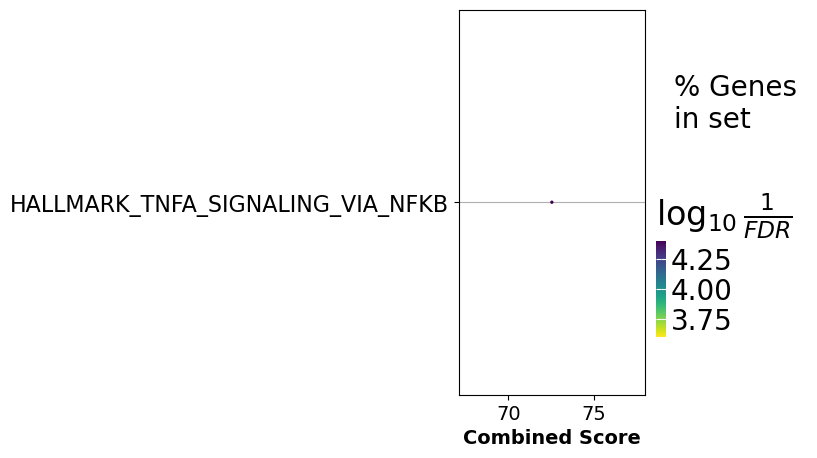

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
39,h.all.v2023.2.Hs.symbols.gmt,HALLMARK_TNFA_SIGNALING_VIA_NFKB,16/200,6.684453e-07,0.000029,5.101635,72.536632,CD83;EGR3;DUSP2;B4GALT1;BTG2;CD69;NR4A2;JUNB;C...


MGIP cells in case2 = 243
2145


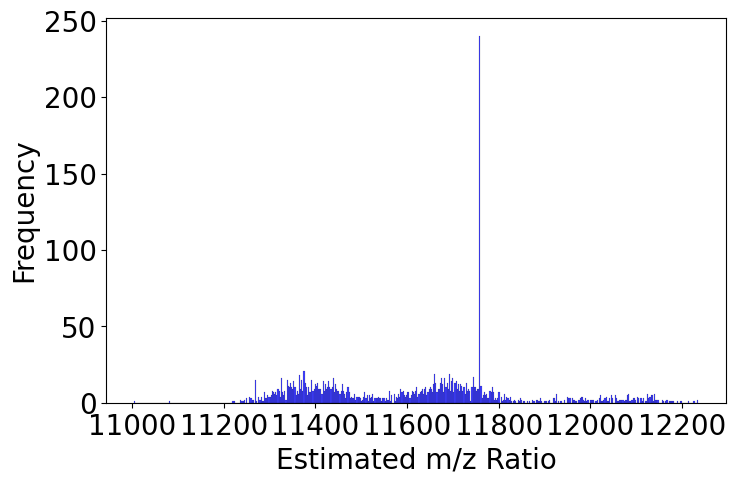

In [2]:

for ssample in ['case1', 'case2']:
    adata = sc.read_h5ad(f'../data/PROMISE_{ssample}.h5ad')

    adata.obs['cell_annot_final'] = np.where(
        adata.obs['cell_annot_v2'].isna(), 
        np.nan, 
        np.where(
            adata.obs['cell_annot_v2'].str.contains('Abnormal', na=False), 
            'Abnormal_BC', 
            adata.obs['cell_annot_v2'] 
        )
    )

    ## skip all NaN adata
    if len(adata.obs['cell_annot_final'].unique())<2:
        continue

    adata.obs['cell_annot_abnormal'] = np.where(
                adata.obs['cell_annot_final'].isna(), 
                np.nan,
                np.where(
                    adata.obs['cell_annot_final'] != 'Abnormal_BC', 
                    'N', 
                    adata.obs['cell_annot_final'] 
                )
    )


    columns_to_drop = ['dref', 'dref_aa']  
    columns_present = [col for col in columns_to_drop if col in adata.obs.columns]
    adata.obs.drop(columns=columns_present, inplace=True)

    bcr_df = pd.read_csv(f'../data/PROMISE_{ssample}_BCR.csv', sep=",")
        
    bcr_df['clonotype_number'] = bcr_df['clonotype_id'].str.extract('(\d+)').astype(float)

    # Use np.where to assign 'clonotype_id' if it's between 1 and 10, else np.nan
    bcr_df['clonotype_top10'] = np.where((bcr_df['clonotype_number'] >= 1) & 
                                            (bcr_df['clonotype_number'] <= 10), 
                                             bcr_df['clonotype_number'].astype(str), 
                                             'Others')
    bcr_df['Unnamed: 0'] = bcr_df['Unnamed: 0'].astype(str) + '_GEX_5'
    
    bcr_df = bcr_df.set_index('Unnamed: 0')

    adata.obs = adata.obs.join(bcr_df, how='left')

    
    
    ## Remove cells without BCR data
    adata = adata[~adata.obs['clonotype_number'].isna()].copy()

    try:
        file_dir = glob.glob(f'/mnt/nfs/workspace/prev_numbat/numbat_total/*{ssample}*/run_numbat*/jobs/0/workspace/*{ssample}*/')
        numbat_df = pd.read_csv('\n'.join(file_dir) + 'clone_post_1.tsv', sep="\t" )
        numbat_df['cell_new'] = numbat_df['cell'] + "-" + sample
        numbat_df.set_index('cell_new', inplace=True)
        numbat_df = numbat_df[numbat_df['p_cnv'] >= 0.95]
        numbat_df = numbat_df[['GT_opt']]
        adata.obs = adata.obs.join(numbat_df, how='left')
    except Exception as e:
        pass
    
    ## full or light-chain only
    adata.obs['heavy_light'] = np.where(
        (adata.obs['heavy_cdr3_aa'] != ".") & (adata.obs['light_cdr3_aa'] != "."), 'full',
        np.where((adata.obs['heavy_cdr3_aa'] == ".") & (adata.obs['light_cdr3_aa'] != "."), 'lc_only', np.nan)
    )

    ## Assign MGIP cells in scRNA
    if ssample == 'case1':
        gaussian_peak = 11620.4 
        ms_peak_second = 11556.4
        heavy = 'IGHM'
        heavy_second = 'IGHM'
    elif ssample == 'case2':
        gaussian_peak = 11759.5 ## Real value not gaussian peak
        ms_peak_second = 11705.6
        heavy = 'IGHM'
        heavy_second = 'IGHA'

    cut = 3

    adata.obs['est_mz_ratio'] = adata.obs['est_mz_ratio'].astype(float)

    adata.obs['MS_group'] = np.where(
        adata.obs['heavy_light'] == 'lc_only', 'LC',
        np.where(
            (adata.obs['est_mz_ratio'] >= gaussian_peak - cut) & (adata.obs['est_mz_ratio'] <= gaussian_peak + cut) & 
            (adata.obs['heavy_c_gene_all_contig'].str.contains(heavy, na=False)), 'MGIP',
            'NaN'
        )
    )
    
    adata.obs['MS_group_2nd_peak'] = np.where(
        adata.obs['heavy_light'] == 'lc_only', 'LC',
        np.where(
            (adata.obs['est_mz_ratio'] >= ms_peak_second - cut) & (adata.obs['est_mz_ratio'] <= ms_peak_second + cut) & 
            (adata.obs['heavy_c_gene_all_contig'].str.contains(heavy_second, na=False)), '2nd_peak_positive',
            'NaN'
        )
    )
    

    print(f'number of cell close to the first MS peak (correspond to scBCR peak)')
    print(adata.obs.groupby(['MS_group', 'clonotype_top10']).size())
    print(adata.obs.groupby(['clonotype_top10', 'MS_group']).size())

    print(f'number of cell close to the second MS peak (not correspond to scBCR peak)')
    print(adata.obs.groupby(['MS_group_2nd_peak']).size())
    
    group = 'MS_group'

    ## save raw expression
    adata_raw = adata.copy()

    ## Normalize and log
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.scale(adata)  

    ## Draw UMAP    
    draw_umap(adata, group, ssample)

    if 'GT_opt' in adata.obs.columns:
        fig, ax = plt.subplots()
        sc.pl.embedding(adata, basis='X_umap', 
                        color = ['GT_opt'],
                        title = 'CNV',
                        ax=ax, show=False
                       )
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")
        fig.savefig(f'../00.Figures/PROMISE_{ssample}_CNV.pdf', format='pdf', bbox_inches='tight')
        plt.show()
        
        ## Print size
        #print(adata.obs.groupby(['GT_opt', 'MS_group']).size())
        #print(adata.obs.groupby(['MS_group', 'GT_opt']).size())
       
    
    ## DEG and gene signature using group by mzdiff
    #if len(adata_raw.obs[ (adata_raw.obs[group]=='Y') & (adata_raw.obs['clonal_aa']>=3) ]) > 1:
    ## DEG
    DEG(adata_raw, 'MS_group', ssample)
    ## Gene score (adata, score name, genes for score, group to be compared)
    gene_score(adata, 'IG', 
               [gene_name for gene_name in adata.var_names if gene_name.startswith('IG')],
               group)
    for score_name in gene_dict.keys():
        gene_score_df = gene_score(adata, score_name, gene_dict[score_name], group) 
        score_dfs.append(gene_score_df)
    
    ######## EST MZ DISTRIBUTION
    input_df = adata.obs.copy()

    ## Count
    mgip_count = len(input_df[input_df['MS_group'] == 'MGIP'])
    print(f'MGIP cells in {ssample} = {mgip_count}')
    
    # Drop NA values if any
    mz_values = input_df['est_mz_ratio'].dropna()
    print(len(mz_values))

    plt.figure(figsize=(8, 5))
    plt.rcParams.update({'font.size': 20})
    sns.histplot(mz_values, bins=500, kde=False, color='blue')  # kde=True adds a density curve
    plt.xlabel('Estimated m/z Ratio')
    plt.ylabel('Frequency')
    plt.savefig(f'../00.Figures/PROMISE_{ssample}_est_mz_ratio_distribution.pdf', format='pdf', bbox_inches='tight')
    plt.show()
        



# 03. Expression signatures

[0.0, 2.2319919211290863e-175, 2.6543532102613926e-128, 0.0013053521218360706, 0.0001868349211271659]

Case 1 (['case1']):
  - CLL: q = 0.00e+00
  - WM: q = 5.58e-175
  - MCL: q = 4.42e-128
  - HCL: q = 1.31e-03
  - Burkitt: q = 2.34e-04
[3.035034252035298e-82, 9.525742871128408e-25, 2.948453600464662e-06, 0.035499614004447164, 0.0008878288096471728]

Case 2 (['case2']):
  - CLL: q = 1.52e-81
  - WM: q = 2.38e-24
  - MCL: q = 4.91e-06
  - HCL: q = 3.55e-02
  - Burkitt: q = 1.11e-03


,score,demux_id,effect_size,mean_diff,pval,sample_label
0,CLL,case1,1.453842,0.270757,0.000000e+00,Case 1
1,CLL,case2,2.003144,0.368945,3.035034e-82,Case 2
2,WM,case1,0.950291,0.225758,2.231992e-175,Case 1
3,WM,case2,0.788686,0.161978,9.525743e-25,Case 2
4,MCL,case1,0.779745,0.249296,2.654353e-128,Case 1
5,MCL,case2,0.353501,0.114679,2.948454e-06,Case 2
6,HCL,case1,0.099508,-0.026046,1.305352e-03,Case 1
7,HCL,case2,0.140058,0.034683,3.549961e-02,Case 2
8,Burkitt,case1,0.114762,-0.030349,1.868349e-04,Case 1
9,Burkitt,case2,0.224205,-0.057934,8.878288e-04,Case 2


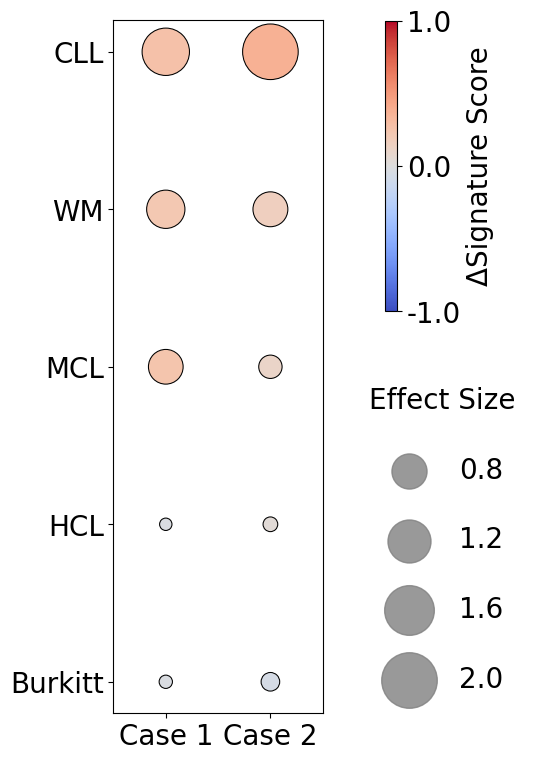

In [8]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import scanpy.external as sce
import os, glob, subprocess, itertools
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from matplotlib import colors
import matplotlib.patches as patches
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.legend import Legend
import matplotlib.lines as mlines
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def cohen_d(group1, group2):
    diff = np.mean(group1) - np.mean(group2)
    pooled_std = np.sqrt((np.var(group1, ddof=1) * (len(group1) - 1) + 
                          np.var(group2, ddof=1) * (len(group2) - 1)) / 
                         (len(group1) + len(group2) - 2))
    return diff / pooled_std if pooled_std != 0 else np.nan

gene_score_final_df = pd.read_csv('../data/PROMISE_gene_signature_score.csv', sep=",")

score_list = ['CLL', 'WM', 'MCL', 'HCL', 'Burkitt'] #, 'Myeloma', 'PC']

group = 'MS matched MGIP'
data = []
# Calculate effect sizes and mean differences for each score and demux_id
for score in score_list:
    for sample in ['case1', 'case2']:
        df = gene_score_final_df[gene_score_final_df['demux_id'] == sample]


        df[group] = np.where(
            df['MS_group'] == 'MGIP',
            'Y', 'N'
        )

        # Separate data by group 'Y' and 'N'
        group1 = df[df[group] == 'Y'][score].dropna()
        group2 = df[df[group] == 'N'][score].dropna()

        # Only proceed if both groups have valid data
        if len(group1) > 0 and len(group2) > 0:
            effect_size = cohen_d(group1, group2)
            mean_diff = group1.mean() - group2.mean()  # Mean difference: Y - N


            df_plot = pd.DataFrame({
                group: ['Y'] * len(group1) + ['N'] * len(group2),
                score: pd.concat([group1, group2])
            })


            # p-value
            tstat, pval = ttest_ind(group1, group2, equal_var=False)

            # Append results
            data.append({
                'score': score,
                'demux_id': sample,
                'effect_size': abs(effect_size),
                'mean_diff': mean_diff,
                'pval' : pval,
            })

plot_data = pd.DataFrame(data)


# Sample label mapping (desired order: Case 1 first)
sample_label_map = {
    'case1': 'Case 1',
    'case2': 'Case 2'
}
plot_data['sample_label'] = plot_data['demux_id'].map(sample_label_map)

# Q-value
for indv in plot_data['sample_label'].unique():
    subset_plot_data = plot_data[plot_data['sample_label'] == indv]
    demux_id = subset_plot_data['demux_id'].unique()
    scores = subset_plot_data['score'].tolist()
    pval_list = subset_plot_data['pval'].tolist()
    print(pval_list)

    # q-value 
    reject, qvals, _, _ = multipletests(pval_list, method='fdr_bh')

    print(f"\n{indv} ({demux_id}):")
    for score, q in zip(scores, qvals):
        print(f"  - {score}: q = {q:.2e}")

# Order x-axis explicitly
sample_order = ['Case 1', 'Case 2']
plot_data['sample_label'] = pd.Categorical(plot_data['sample_label'], categories=sample_order, ordered=True)

display(plot_data)
# Set y-axis order (reverse if needed)
score_order = score_list

# Plot
fig, ax = plt.subplots(figsize=(3, 9)) 
size_scale = 800              # Cohen’s d
min_s  = plot_data['effect_size'].min() * size_scale
max_s  = plot_data['effect_size'].max() * size_scale
norm = Normalize(vmin=-1, vmax=1)

scatter = sns.scatterplot(
    data=plot_data,
    x='sample_label',
    y='score',
    size='effect_size',
    sizes=(min_s, max_s),    
    hue='mean_diff',
    palette='coolwarm',
    hue_norm=norm,
    alpha=1,
    edgecolor='black',
    legend=False,
    ax=ax
)

# Axis labels & ticks
font_size = 20
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size) 
plt.xlabel('', fontsize=font_size)
plt.ylabel('', fontsize=font_size) #plt.ylabel('Signature Score', fontsize=font_size)

# Colorbar (for hue)
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm,
                ax=ax,
                fraction=0.05,   
                pad=0.05,       
                aspect=25)
tick_values = [-1.0, 0.0, 1.0]
cbar.set_ticks(tick_values)
cbar.set_ticklabels([str(v) for v in tick_values])
cbar.ax.set_ylabel('ΔSignature Score', fontsize=font_size) # Mean Signature Score Difference
cbar.ax.tick_params(labelsize=font_size)

box = cbar.ax.get_position()
cbar.ax.set_position([box.x0 + 0.17, box.y0 + 0.2615, box.width, box.height * 0.9])


ax.set_xlim(-0.5, 1.5)        
ax.set_xticklabels(['Case 1', 'Case 2'], fontsize=font_size)

# Size legend (manual)
sizes_for_legend = [0.8, 1.2, 1.6, 2.0]
for s in sizes_for_legend:
    ax.scatter([], [], s=s*size_scale, c='gray', label=f'{s:.1f}', alpha=0.8)

ax.legend(
    title='Effect Size',
    title_fontsize=font_size,
    fontsize=font_size,
    loc='center left',
    bbox_to_anchor=(1.1, 0.25),
    labelspacing=1.5,
    frameon=False  
)

#plt.tight_layout()
group_name = "".join(group.split(" "))
plt.savefig(f'../00.Figures/PROMISE_signature_comp_{group_name}_vertical.pdf', format='pdf', bbox_inches='tight')
plt.show()